# Практика 22. Часовий ряд

**Варіант:** 7  
**Місто:** Івано-Франківськ  
**Тип даних:** щомісячний часовий ряд температури

У роботі будується 10-річний щомісячний часовий ряд температури з урахуванням середньорічної температури, сезонної складової, лінійного тренду потепління та випадкового шуму.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(7)

base_temp = 7.8
amplitude = 12
trend_per_year = 0.02
noise_scale = 0.8
city = "Ivano-Frankivsk"

n_years = 10

dates = pd.date_range(
    start="2015-01-01",
    periods=n_years * 12,
    freq="MS"
)

month = dates.month

years_elapsed = (
    (dates.year - dates.year[0])
    + (dates.month - 1) / 12
)

seasonal = amplitude * np.cos(
    (month - 7) / 12 * 2 * np.pi
)

trend = trend_per_year * years_elapsed

noise = np.random.normal(
    0,
    noise_scale,
    len(dates)
)

temp = np.round(
    base_temp + trend + seasonal + noise,
    1
)

climate_ts = pd.Series(
    temp,
    index=dates,
    name="temperature"
)

print(climate_ts.head(12))
print("Number of observations:", len(climate_ts))

2015-01-01    -2.8
2015-02-01    -3.0
2015-03-01     1.8
2015-04-01     8.1
2015-05-01    13.2
2015-06-01    18.2
2015-07-01    19.8
2015-08-01    16.8
2015-09-01    14.6
2015-10-01     8.3
2015-11-01     1.3
2015-12-01    -2.7
Freq: MS, Name: temperature, dtype: float64
Number of observations: 120


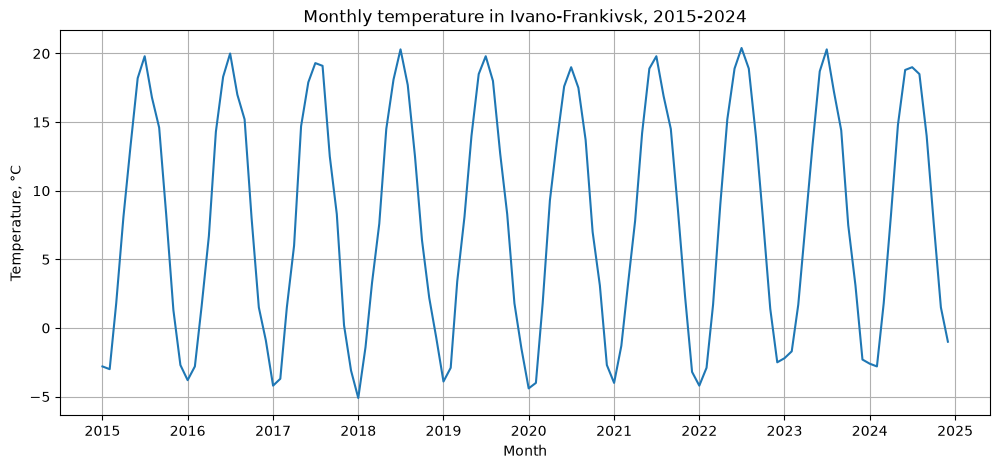

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values
)

ax.set_xlabel("Month")
ax.set_ylabel("Temperature, °C")
ax.set_title(
    "Monthly temperature in Ivano-Frankivsk, 2015-2024"
)

ax.grid(True)

plt.show()

### Аналіз

На графіку спостерігаються чіткі сезонні коливання температури протягом кожного року. Найвищі значення припадають приблизно на літні місяці, а найнижчі — на зимові.

Через невелике значення тренду потепління 0.02 °C на рік загальний підйом рівня температури за 10 років є невеликим, тому він менш помітний візуально, ніж річна сезонність. Водночас у довгостроковій перспективі рівень ряду має слабку тенденцію до зростання.

## Завдання 2. Ковзне середнє при різних вікнах

Для порівняння використаємо центровані ковзні середні з вікнами 3 та 12 місяців, а також трейлінгове 12-місячне ковзне середнє.

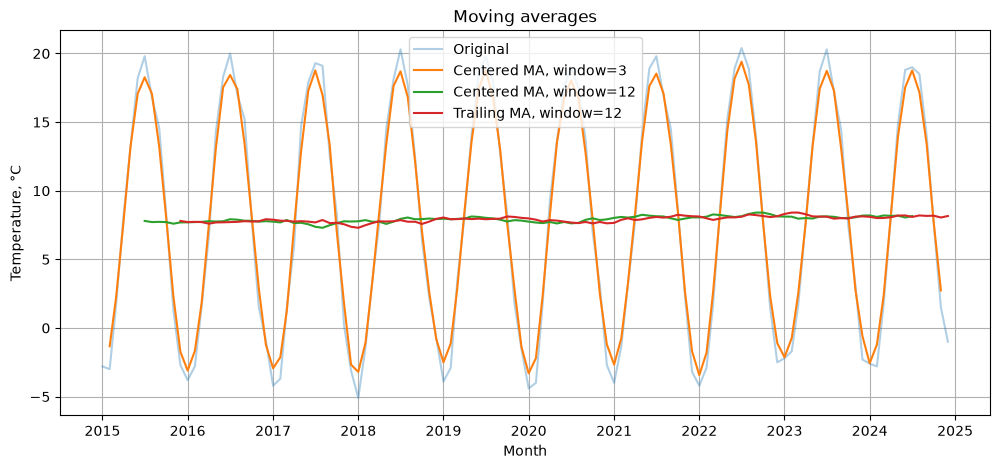

In [3]:
ma3 = climate_ts.rolling(
    window=3,
    center=True
).mean()

ma12_centered = climate_ts.rolling(
    window=12,
    center=True
).mean()

ma12_trailing = climate_ts.rolling(
    window=12
).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    alpha=0.35,
    label="Original"
)

ax.plot(
    ma3.index,
    ma3.values,
    label="Centered MA, window=3"
)

ax.plot(
    ma12_centered.index,
    ma12_centered.values,
    label="Centered MA, window=12"
)

ax.plot(
    ma12_trailing.index,
    ma12_trailing.values,
    label="Trailing MA, window=12"
)

ax.set_xlabel("Month")
ax.set_ylabel("Temperature, °C")
ax.set_title("Moving averages")

ax.legend()
ax.grid(True)

plt.show()

### Аналіз ковзного середнього

Ковзне середнє з вікном 3 місяці зменшує короткостроковий випадковий шум, але сезонні коливання залишаються добре помітними.

Вікно 12 місяців охоплює повний річний сезонний цикл. Тому центроване 12-місячне середнє значно краще прибирає сезонну складову та показує переважно довгостроковий тренд.

Трейлінгове 12-місячне середнє використовує лише поточне та попередні спостереження. Через це воно реагує на зміни із запізненням. На графіку це проявляється як систематичне зміщення згладженої кривої відносно центрованої.

Центроване ковзне середнє не можна безпосередньо використовувати в режимі реального часу, оскільки для його обчислення потрібні також майбутні значення часового ряду.

## Завдання 3. Декомпозиція часового ряду

Застосуємо адитивну декомпозицію на тренд, сезонність та залишок.

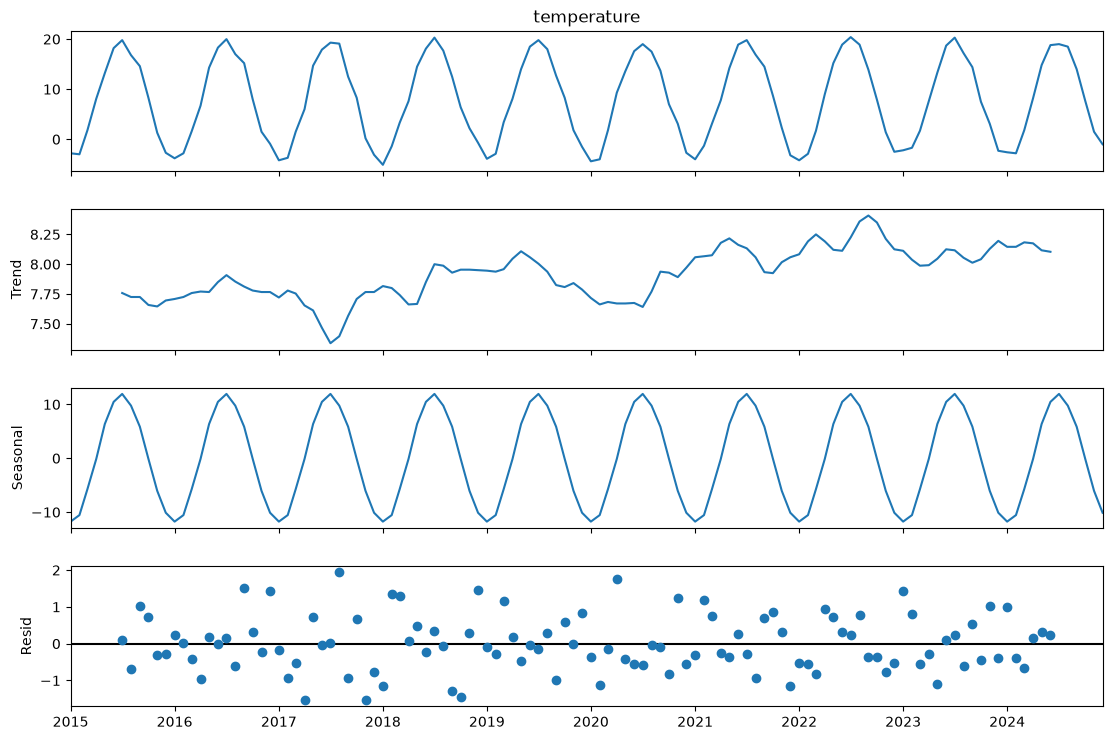

In [5]:
decomposition = seasonal_decompose(
    climate_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()

fig.set_size_inches(12, 8)

plt.show()

In [6]:
trend_component = decomposition.trend.dropna()
seasonal_component = decomposition.seasonal
residual_component = decomposition.resid.dropna()

print("Trend:")
print(trend_component.head())

print("\nSeasonal component:")
print(seasonal_component.head(12).round(2))

print("\nResidual standard deviation:")
print(round(residual_component.std(), 3))

Trend:
2015-07-01    7.758333
2015-08-01    7.725000
2015-09-01    7.725000
2015-10-01    7.658333
2015-11-01    7.645833
Freq: MS, Name: trend, dtype: float64

Seasonal component:
2015-01-01   -11.75
2015-02-01   -10.55
2015-03-01    -5.73
2015-04-01    -0.12
2015-05-01     6.36
2015-06-01    10.47
2015-07-01    11.94
2015-08-01     9.77
2015-09-01     5.86
2015-10-01    -0.09
2015-11-01    -6.04
2015-12-01   -10.11
Freq: MS, Name: seasonal, dtype: float64

Residual standard deviation:
0.761


In [7]:
seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)

warmest_month = seasonal_by_month.idxmax()
coldest_month = seasonal_by_month.idxmin()

print("Warmest month:", warmest_month)
print("Coldest month:", coldest_month)

print("\nSeasonal values by month:")
print(seasonal_by_month.round(2))

Warmest month: 7
Coldest month: 1

Seasonal values by month:
1    -11.75
2    -10.55
3     -5.73
4     -0.12
5      6.36
6     10.47
7     11.94
8      9.77
9      5.86
10    -0.09
11    -6.04
12   -10.11
Name: seasonal, dtype: float64


### Аналіз декомпозиції

Оцінений тренд має загалом зростаючий характер. Його нахил відповідає закладеному під час генерації тренду потепління, хоча оцінка містить вплив випадкового шуму.

Сезонна компонента має чітку періодичність із періодом 12 місяців. Найвищі значення сезонної складової спостерігаються влітку, приблизно в районі липня, а найнижчі — взимку. Це відповідає використаній під час генерації формулі з косинусом і амплітуді 12 °C.

Залишкова компонента описує випадкові відхилення, які не пояснюються трендом і сезонністю. Її стандартне відхилення має бути близьким до заданого під час генерації noise_scale = 0.8 °C, хоча через скінченну кількість спостережень точного збігу очікувати не слід.

## Завдання 4. Прогноз на 12 місяців уперед

Для прогнозування використаємо лінійну регресію для очищеного тренду та додамо типовий сезонний ефект відповідного календарного місяця.

In [8]:
trend_clean = decomposition.trend.dropna()

x = np.arange(len(trend_clean))

fit = linregress(
    x,
    trend_clean.values
)

print("Slope:", fit.slope)
print("Intercept:", fit.intercept)
print("p-value:", fit.pvalue)
print("Standard error:", fit.stderr)

Slope: 0.0050558945509858585
Intercept: 7.648298221769169
p-value: 1.6018578196137835e-20
Standard error: 0.0004368120130113339


In [9]:
n_ahead = 12

x_future = np.arange(
    len(trend_clean),
    len(trend_clean) + n_ahead
)

trend_forecast = (
    fit.intercept
    + fit.slope * x_future
)

seasonal_by_month = (
    decomposition.seasonal
    .groupby(decomposition.seasonal.index.month)
    .mean()
)

future_dates = pd.date_range(
    climate_ts.index[-1] + pd.offsets.MonthBegin(1),
    periods=n_ahead,
    freq="MS"
)

seasonal_forecast = (
    seasonal_by_month
    .reindex(future_dates.month)
    .values
)

forecast = pd.Series(
    trend_forecast + seasonal_forecast,
    index=future_dates,
    name="forecast"
)

print(forecast.round(1))

2025-01-01    -3.6
2025-02-01    -2.3
2025-03-01     2.5
2025-04-01     8.1
2025-05-01    14.6
2025-06-01    18.7
2025-07-01    20.2
2025-08-01    18.0
2025-09-01    14.1
2025-10-01     8.1
2025-11-01     2.2
2025-12-01    -1.9
Freq: MS, Name: forecast, dtype: float64


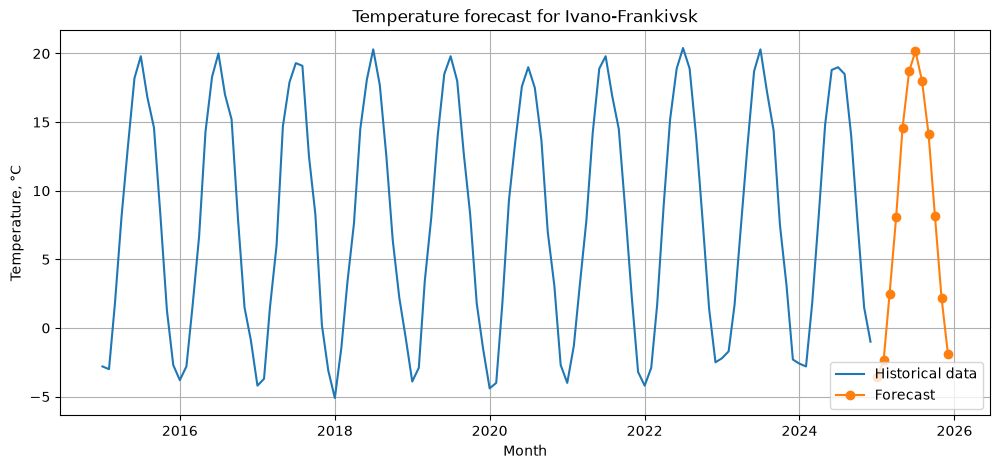

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    climate_ts.index,
    climate_ts.values,
    label="Historical data"
)

ax.plot(
    forecast.index,
    forecast.values,
    marker="o",
    label="Forecast"
)

ax.set_xlabel("Month")
ax.set_ylabel("Temperature, °C")
ax.set_title(
    "Temperature forecast for Ivano-Frankivsk"
)

ax.legend()
ax.grid(True)

plt.show()

### Застереження щодо прогнозу

Отриманий прогноз є математичною екстраполяцією виявленого тренду та сезонності, а не точною передбачуваною моделлю майбутньої погоди.

Модель припускає, що швидкість зміни температури та сезонний характер залишатимуться приблизно такими самими, як у навчальному періоді. У реальності на температуру можуть впливати зміни клімату, аномальні погодні явища, атмосферні процеси та інші фактори, яких немає в моделі.

Тому прогноз на наступні 12 місяців слід розглядати як демонстрацію методу екстраполяції, а не як гарантовані значення температури. Чим далі прогноз виходить за межі наявних даних, тим менш надійним стає просте продовження лінійного тренду.

## Завдання 5. Реальний тренд чи шум на короткому вікні

Перевіримо статистичну значущість оціненого нахилу за допомогою p-value та побудуємо приблизний 95% довірчий інтервал.

In [11]:
alpha = 0.05

slope = fit.slope
stderr = fit.stderr
pvalue = fit.pvalue

ci_low = slope - 1.96 * stderr
ci_high = slope + 1.96 * stderr

print("Slope =", slope)
print("Standard error =", stderr)
print("p-value =", pvalue)

print("95% confidence interval:")
print("[", ci_low, ",", ci_high, "]")

if pvalue < alpha:
    print("H0 rejected: the trend is statistically significant.")
else:
    print("H0 not rejected: the trend is not statistically significant.")

Slope = 0.0050558945509858585
Standard error = 0.0004368120130113339
p-value = 1.6018578196137835e-20
95% confidence interval:
[ 0.004199743005483644 , 0.005912046096488073 ]
H0 rejected: the trend is statistically significant.


In [12]:
short_ts = climate_ts.iloc[-36:]

short_decomposition = seasonal_decompose(
    short_ts,
    model="additive",
    period=12
)

short_trend = short_decomposition.trend.dropna()

x_short = np.arange(len(short_trend))

fit_short = linregress(
    x_short,
    short_trend.values
)

print("Last 3 years:")
print("Slope =", fit_short.slope)
print("p-value =", fit_short.pvalue)
print("Standard error =", fit_short.stderr)

Last 3 years:
Slope = -0.0059166666666665944
p-value = 0.06982126289666465
Standard error = 0.003104499069221126


### Статистичний аналіз тренду

Нульова гіпотеза:

**H0:** істинний нахил температурного тренду дорівнює нулю, тобто реального потепління немає, а спостережувана зміна може бути пояснена випадковим шумом.

Альтернативна гіпотеза:

**H1:** істинний нахил тренду відрізняється від нуля.

Рішення приймається за рівнем значущості α = 0.05. Якщо p-value < 0.05, нульову гіпотезу відхиляємо та вважаємо тренд статистично значущим. Якщо p-value ≥ 0.05, підстав відхиляти H0 недостатньо.

95% довірчий інтервал для нахилу обчислюється приблизно як:

slope ± 1.96 × stderr

Якщо цей інтервал не містить нуль, це узгоджується зі статистично значущим трендом на рівні приблизно 5%.

Окремий розрахунок за останні три роки може дати інший нахил. На коротшому часовому інтервалі випадковий шум сильніше впливає на оцінку, тому короткий період може показувати як сильніше, так і слабше потепління. Саме тому для оцінювання довгострокового тренду доцільніше використовувати весь доступний десятирічний ряд.

Таким чином, висновок про наявність статистично підтвердженого тренду потрібно робити не лише за додатним значенням slope, а насамперед за p-value та довірчим інтервалом.

## Контрольні питання

### 1. Чому часовий ряд не можна аналізувати точно так само, як звичайну незалежну вибірку?

У часовому ряді сусідні спостереження часто пов'язані між собою. Значення температури цього місяця залежить від погодних умов попередніх місяців, а також існує регулярна сезонність.

Тому припущення про повністю незалежні спостереження, характерне для багатьох методів аналізу звичайної вибірки, може бути порушене. У часовому ряді потрібно враховувати порядок спостережень, тренд, сезонність та автокореляцію.

### 2. Чому надто мале й надто велике вікно ковзного середнього є проблемою?

Надто мале вікно недостатньо згладжує випадковий шум і сезонні коливання. Надто велике вікно, навпаки, може надмірно згладити дані та приховати важливі зміни.

Розмір вікна доцільно узгоджувати з періодом сезонності. Для щомісячних даних із річною сезонністю природним вибором є вікно 12 місяців.

### 3. У чому різниця між трейлінговим і центрованим ковзним середнім?

Трейлінгове ковзне середнє використовує поточне та попередні значення. Воно може бути обчислене в реальному часі, але реагує на зміни із певним лагом.

Центроване ковзне середнє використовує значення як до, так і після поточного моменту. Воно краще відображає положення згладженої кривої, але для його розрахунку потрібні майбутні дані. Тому в режимі реального часу його безпосередньо застосувати неможливо.

### 4. Чому p-value важливіше за сам знак slope?

Додатний slope лише показує, що оцінена лінія має позитивний нахил. Це ще не доводить наявність реального тренду, оскільки позитивний нахил може виникнути випадково через шум.

p-value дозволяє перевірити нульову гіпотезу про відсутність реального тренду. Якщо p-value менше 0.05, є статистичні підстави вважати нахил відмінним від нуля. Тому для висновку про статистично підтверджене потепління потрібно враховувати p-value, а не тільки додатний знак slope.